In [9]:
import numpy as np
import pandas as pd

In [10]:
from pydataset import data
mtcars = data('mtcars')
mtcars.head(3)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1


In [11]:
mtcars.describe(include='all')

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [12]:
# Convert selected columns to category
mtcars = data('mtcars')
mtcars = mtcars.astype({ 'cyl':'category', 'vs': 'category',  'carb': 'category',  
                         'am':   'category',  'gear':  'category' } )


In [5]:
mtcars.describe(include='all')

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.0,32.000000,32.000000,32.000000,32.000000,32.000000,32.0,32.0,32.0,32.0
unique,NaN,3.0,NaN,NaN,NaN,NaN,NaN,2.0,2.0,3.0,6.0
top,NaN,8.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,3.0,2.0
freq,NaN,14.0,NaN,NaN,NaN,NaN,NaN,18.0,19.0,15.0,10.0
mean,20.090625,NaN,230.721875,146.687500,3.596563,3.217250,17.848750,NaN,NaN,NaN,NaN
std,6.026948,NaN,123.938694,68.562868,0.534679,0.978457,1.786943,NaN,NaN,NaN,NaN
min,10.400000,NaN,71.100000,52.000000,2.760000,1.513000,14.500000,NaN,NaN,NaN,NaN
25%,15.425000,NaN,120.825000,96.500000,3.080000,2.581250,16.892500,NaN,NaN,NaN,NaN
50%,19.200000,NaN,196.300000,123.000000,3.695000,3.325000,17.710000,NaN,NaN,NaN,NaN
75%,22.800000,NaN,326.000000,180.000000,3.920000,3.610000,18.900000,NaN,NaN,NaN,NaN


# Assistant
# Understanding NaN Values in `describe()` Output

The `unique`, `top`, and `freq` statistics in pandas' `describe(include='all')` output show NaN for numeric columns (like mpg, hp, drat, qsec, vs, am) because these statistics only apply to categorical/object data types.

## Explanation:

When you call `mtcars.describe(include='all')`, pandas produces different statistics based on column data types:

- **For numeric columns** (like mpg, hp, drat, qsec):
  - Shows count, mean, std, min, 25%, 50%, 75%, max
  - Shows NaN for unique, top, freq (these don't apply to numeric data)

- **For categorical/object columns**:
  - Shows count, unique, top, freq
  - Shows NaN for mean, std, min, percentiles, max

## Solution:

If you want to see these statistics for numeric columns, you need to convert them to categorical type first:


In [6]:
# To see unique values for numeric columns
for col in ['mpg', 'hp', 'drat', 'qsec', 'vs', 'am']:
    print(f"\n{col} unique values: {mtcars[col].nunique()}")
    print(f"{col} value counts:\n{mtcars[col].value_counts().head()}")

# Alternative: convert specific columns to category type before describe
mtcars_cat = mtcars.copy()
mtcars_cat[['mpg', 'hp', 'drat', 'qsec', 'vs', 'am']] = mtcars_cat[['mpg', 'hp', 'drat', 'qsec', 'vs', 'am']].astype('category')
mtcars_cat.describe(include='all')


mpg unique values: 25
mpg value counts:
mpg
21.0    2
22.8    2
21.4    2
19.2    2
15.2    2
Name: count, dtype: int64

hp unique values: 22
hp value counts:
hp
110    3
175    3
180    3
245    2
123    2
Name: count, dtype: int64

drat unique values: 22
drat value counts:
drat
3.92    3
3.07    3
3.90    2
3.08    2
3.15    2
Name: count, dtype: int64

qsec unique values: 30
qsec value counts:
qsec
17.02    2
18.90    2
16.46    1
18.61    1
19.44    1
Name: count, dtype: int64

vs unique values: 2
vs value counts:
vs
0    18
1    14
Name: count, dtype: int64

am unique values: 2
am value counts:
am
0    19
1    13
Name: count, dtype: int64


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.0,32.0,32.000000,32.0,32.00,32.000000,32.00,32.0,32.0,32.0,32.0
unique,25.0,3.0,NaN,22.0,22.00,NaN,30.00,2.0,2.0,3.0,6.0
top,10.4,8.0,NaN,110.0,3.07,NaN,17.02,0.0,0.0,3.0,2.0
freq,2.0,14.0,NaN,3.0,3.00,NaN,2.00,18.0,19.0,15.0,10.0
mean,NaN,NaN,230.721875,NaN,NaN,3.217250,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,123.938694,NaN,NaN,0.978457,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,71.100000,NaN,NaN,1.513000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,120.825000,NaN,NaN,2.581250,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,196.300000,NaN,NaN,3.325000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,326.000000,NaN,NaN,3.610000,NaN,NaN,NaN,NaN,NaN


This approach will let you see the unique count and most frequent values for these columns.

In [16]:
mtcars[mtcars['mpg'].between(23, 30) & (mtcars['am'] == 1)] 

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Fiat X1-9,27.3,4,79.0,66,4.08,1.935,18.9,1,1,4,1
Porsche 914-2,26.0,4,120.3,91,4.43,2.140,16.7,0,1,5,2


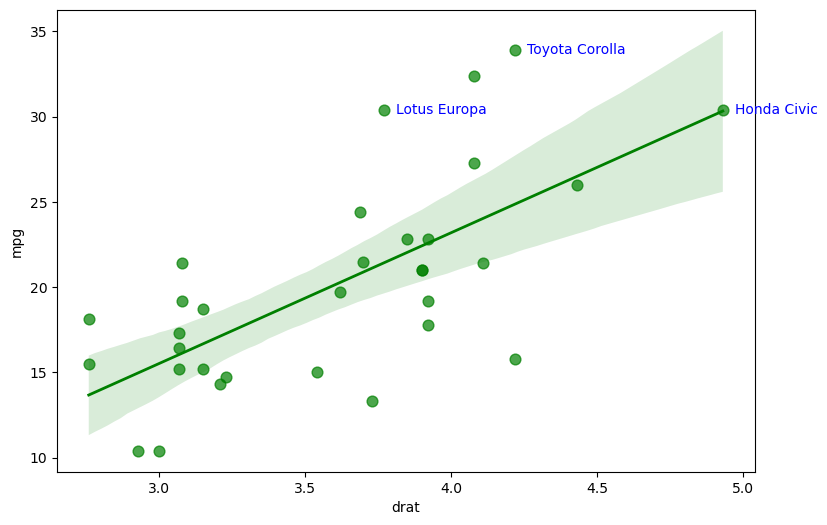

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pydataset import data

df = data('mtcars')
plt.figure(figsize=(9, 6))
sns.regplot(
    data=df, 
    x='drat', 
    y='mpg',
    scatter_kws={'s':60, 'alpha': 0.7, 'color': 'green'},
    line_kws={'color': 'green', 'lw': 2}
)
# Annotate specific high-performing "mystery" models
top_performers = df.loc[['Honda Civic', 'Lotus Europa', 'Toyota Corolla']]  # Extract specific car models
for model, row in top_performers.iterrows():
    # Add text labels next to points
    plt.text(row['drat']+0.04, row['mpg'], model, fontsize=10, verticalalignment='center',color = 'blue')  


plt.show()


# Assistant
# Explanation of `sns.regplot` and the for loop

## `sns.regplot`


<Axes: xlabel='drat', ylabel='mpg'>

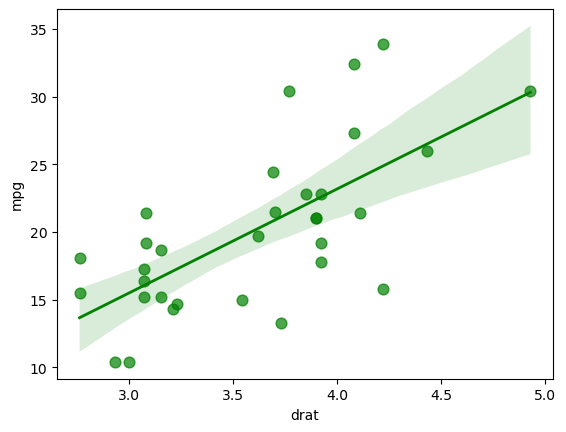

In [2]:
sns.regplot(
    data=df, 
    x='drat', 
    y='mpg',
    scatter_kws={'s':60, 'alpha': 0.7, 'color': 'green'},
    line_kws={'color': 'green', 'lw': 2}
)


`sns.regplot` creates a scatter plot with a fitted regression line. Here's a detailed breakdown:

1. `data=df` - Specifies the DataFrame to use (the mtcars dataset)
2. `x='drat'` - Uses the 'drat' column (rear axle ratio) for the x-axis
3. `y='mpg'` - Uses the 'mpg' column (miles per gallon) for the y-axis
4. `scatter_kws` - A dictionary of keyword arguments for customizing the scatter plot points:
   - `'s':60` - Sets the size of the markers to 60
   - `'alpha': 0.7` - Makes the markers semi-transparent (70% opacity)
   - `'color': 'green'` - Colors all markers green
5. `line_kws` - A dictionary of keyword arguments for customizing the regression line:
   - `'color': 'green'` - Makes the regression line green
   - `'lw': 2` - Sets the line width to 2 points

## For Loop


In [ ]:
top_performers = df.loc[['Honda Civic', 'Lotus Europa', 'Toyota Corolla']]  # Extract specific car models
for model, row in top_performers.iterrows():
    # Add text labels next to points
    plt.text(row['drat']+0.04, row['mpg'], model, fontsize=10, verticalalignment='center',color = 'blue')  



This loop annotates specific car models on the plot:

1. `top_performers.iterrows()` - Creates an iterator that yields pairs of (index, row) for each row in the `top_performers` DataFrame
   - `model` - Captures the index value (car model name)
   - `row` - Captures the actual row data as a Series

2. For each car model in the loop:
   - `plt.text()` adds a text annotation to the plot with these parameters:
     - `row['drat']+0.04` - x-coordinate (slightly offset to the right of the point)
     - `row['mpg']` - y-coordinate
     - `model` - The text to display (car model name)
     - `fontsize=10` - Sets the font size
     - `verticalalignment='center'` - Centers the text vertically
     - `color='blue'` - Sets the text color to blue

The loop effectively labels three specific car models (Honda Civic, Lotus Europa, Toyota Corolla) that are considered "top performers" in the dataset.